# 1. Introdução

- **Aluno:** Pedro Yutaro Mont Morency Nakamura  
- **Data:** 17/05/2026
- **Objetivo:** Implementar e otimizar a abordagem de representação textual baseada em frequência (espaço esparso de alta dimensionalidade). É aqui que reside o modelo campeão do projeto.

## 1.1 Sobre o notebook

O trabalho inteiro foi feito em 3 notebooks separados, sendo eles:
- **analysis.ipynb:** Destinado a levantar 11 Questões (denominadas "Q") referente a análises de dados e validação das principais hipóteses que fundamentam as decisões tomadas no presente notebook;
- **fase-1.ipynb:** Solução baseada em abordagem linear (Modelagem baseada em frequência léxica, operando num espaço esparso de alta dimensionalidade matemática);
- **fase-2.ipynb:** Solução baseada em abordagem densa (Modelos não-lineares, árvores de decisão e a transição para a representação contínua de semântica vetorial);

### Todos os notebooks e análises podem ser conferidas diretamente nas branches do repositório público do Github como se segue:
#### GitHub do Projeto: https://github.com/PedroYutaroUEA/gender-prediction-challenge/



Este notebook compreende a implementação da **Fase 1** do projeto de predição de gênero com base em revisões de e-commerce.

Aqui, aplicamos técnicas de extração de características textuais baseadas em frequência (N-gramas de palavras e caracteres), integradas a metadados estruturais, estilométricos e demográficos através de um pipeline robusto do Scikit-Learn.

## 1.2 Configurações e Importações de Dependẽncias e Dados

In [ ]:
import os
import time
import pickle
import pandas as pd
import numpy as np

# Visualização de Dados
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-Processamento
import re
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
import spacy

# Classificadores e seleção
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Validação e busca de hiperparâmetros
from sklearn.base import clone, BaseEstimator, TransformerMixin
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline, FeatureUnion

## 1.3 Configuração de Gráficos

In [73]:
# Configurações de exibição do Pandas
pd.set_option('display.max_columns', None)

In [74]:
# Configurações de visualização
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

## 1.4 Carregamento do modelo SpaCy para Português

In [75]:
try:
    # Carrega apenas componentes necessarios para POS/lemmas.
    disable=["parser", "ner"]
    nlp = spacy.load("pt_core_news_lg", disable=disable)
    print("✅ SpaCy pt_core_news_lg carregado com sucesso!")
except Exception as e:
    print(f"❌ Erro ao carregar o modelo: {e}")

✅ SpaCy pt_core_news_lg carregado com sucesso!


---

# 2. Exploração dos Dados

In [76]:
# Caminhos para os dados
TRAIN_PATH = 'treino.csv'
VALIDATION_PATH = 'validacao.csv'

print("Carregando os datasets brutos...")
try:
    df_train_raw = pd.read_csv(TRAIN_PATH, encoding='utf-8', low_memory=False)
    df_val_raw = pd.read_csv(VALIDATION_PATH, encoding='utf-8', low_memory=False)
    print(f"Dataset de Treino carregado: {df_train_raw.shape[0]} linhas e {df_train_raw.shape[1]} colunas.")
    print(f"Dataset de Validação carregado: {df_val_raw.shape[0]} linhas and {df_val_raw.shape[1]} colunas.")
except FileNotFoundError as e:
    print(f"Erro: Certifique-se de que os arquivos 'treino.csv' e 'validacao.csv' estão no mesmo diretório. {e}")

Carregando os datasets brutos...
Dataset de Treino carregado: 76942 linhas e 14 colunas.
Dataset de Validação carregado: 25647 linhas and 14 colunas.


## 2.1 Informações Gerais:

In [22]:
df_train_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 76942 entries, 0 to 76941
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   submission_date        76942 non-null  str    
 1   reviewer_id            76942 non-null  str    
 2   product_id             76942 non-null  str    
 3   product_name           76903 non-null  str    
 4   product_brand          24162 non-null  str    
 5   site_category_lv1      76942 non-null  str    
 6   site_category_lv2      74687 non-null  str    
 7   review_title           76776 non-null  str    
 8   overall_rating         76942 non-null  int64  
 9   recommend_to_a_friend  76932 non-null  str    
 10  review_text            75056 non-null  str    
 11  reviewer_birth_year    75753 non-null  float64
 12  reviewer_gender        76942 non-null  str    
 13  reviewer_state         76942 non-null  str    
dtypes: float64(1), int64(1), str(12)
memory usage: 8.2 MB


In [23]:
df_train_raw.isna().sum()

submission_date              0
reviewer_id                  0
product_id                   0
product_name                39
product_brand            52780
site_category_lv1            0
site_category_lv2         2255
review_title               166
overall_rating               0
recommend_to_a_friend       10
review_text               1886
reviewer_birth_year       1189
reviewer_gender              0
reviewer_state               0
dtype: int64

In [24]:
df_val_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 25647 entries, 0 to 25646
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   submission_date        25647 non-null  str    
 1   reviewer_id            25647 non-null  str    
 2   product_id             25647 non-null  int64  
 3   product_name           25629 non-null  str    
 4   product_brand          8048 non-null   str    
 5   site_category_lv1      25645 non-null  str    
 6   site_category_lv2      24875 non-null  str    
 7   review_title           25598 non-null  str    
 8   overall_rating         25647 non-null  int64  
 9   recommend_to_a_friend  25646 non-null  str    
 10  review_text            25044 non-null  str    
 11  reviewer_birth_year    25242 non-null  float64
 12  reviewer_gender        25647 non-null  str    
 13  reviewer_state         25647 non-null  str    
dtypes: float64(1), int64(2), str(11)
memory usage: 2.7 MB


In [25]:
df_val_raw.isna().sum()

submission_date              0
reviewer_id                  0
product_id                   0
product_name                18
product_brand            17599
site_category_lv1            2
site_category_lv2          772
review_title                49
overall_rating               0
recommend_to_a_friend        1
review_text                603
reviewer_birth_year        405
reviewer_gender              0
reviewer_state               0
dtype: int64

## 2.2 Perguntas de Pesquisas:

#### - Q1: A marca do produto (mesmo sendo apenas 32% presente no dataset), possui alguma correlação com o gênero do reviwer?
#### - Q2: Gênero vs. Categorias (site_category_lv1): Existem categorias de produtos onde um gênero comenta mais que o outro? (Ex: Maquiagem vs. Ferramentas)
#### - Q3: Gênero vs. Avaliação (overall_rating): Homens ou mulheres tendem a ser mais críticos ou elogiosos nas estrelas?.
#### - Q4: Existe uma diferença estatisticamente relevante no tamanho das mensagens escritas por homens e mulheres?.
#### - Q5: Existe um gênero que tende a recomendar o produto mesmo dando notas baixas (3 ou 4)?
#### - Q6: O uso de múltiplas exclamações (ex: "Amei!!!"), letras repetidas ("Linnnnndo") ou textos em "caixa-alta" é mais frequente em qual gênero?
#### - Q7: Há variação no volume de reviews entre janeiro e maio de 2018 para cada gênero? (ex: dia das mães, dia das mulheres ou dia dos pais).
#### - Q8: Como a idade (reviewer_birth_year) se distribui entre os gêneros?.
#### - Q9: Quais são os termos mais discriminativos (Dicionário Latente) por gênero? => Construir diciońario
#### - Q10: Existe diferença na distribuição do volume de Classes Gramaticais (POS Tags)? (O artigo buscou a flexão do adjetivo.)
#### - Q11: Quais são os termos comuns/indiferentes que se diferem dos mais frequentes em relação ao gênero?

## Observação: Para não ficar muito grande, irei repassar apenas as respostas a essas questões (todas as evidências estarão no Github)

## Conclusões Preliminares Q1 - Q4:
1. Q1: A marca do produto possui correlação com o gênero? Sim, aparentemente, há uma correlação.
2. Q2: Apresenta uma forte correlação
3. Q3: Não apresenta correlação
4. Q4: Como p < 0.5, posso dizer que sim, há uma diferença estatisticamente relevante entre a distribuição de wordcount por gênero

## Resultados Q[5-8]:
- Q5: A diferença entre homens e mulheres ao recomendar um produto com nota média é ínfima (94,8% vs 95,5%) => Ambos tendem a recomendar. coluna recommend_to_a_friend pode ser descartada.
- Q6: Mulheres usam múltiplas pontuações (17,4% vs 15,2%) e letras repetidas (1,7% vs 1,4%) com um pouco mais de frequência. => Exige etapa de pre-processamento.
- Q7: A ausência de picos anômalos ou inversões de proporção entre os meses indica que o comportamento temporal é estável. => A coluna submission_date pode ser descartada.
- Q8: Os homens no dataset são, em média, 2 anos mais velhos que as mulheres (mediana de 39 vs 37). => A coluna reviewer_birth_year é um atributo secundário válido.

## Conclusão preliminar do Q9:
- As pessoas utilizam a primeira pessoa do singular e flexionam o adjetivo/particípio para o seu próprio gênero na hora de avaliar.
- A categoria do produto (validado na Q2) reflete diretamente no vocabulário usado no texto.

## Análise dos Resultados de Q10:
- Masculino (noun_ratio e propn_ratio maiores): Foco em objetos, entidades e especificações técnicas (Nomes Próprios e Substantivos). Eles avaliam o que o produto é.
- Feminino (adj_ratio e verb_ratio maiores): Foco em qualidades, percepções e ações (Adjetivos e Verbos). Elas avaliam como se sentiram com o produto ou o serviço.

## Resultado da análise Q11 (Extração Data-Driven de Stop Words do Domínio)
Domain-Specific Stop Words geradas pelos dados:
['produto', 'recomendo', 'entrega', 'excelente', 'ótimo', 'qualidade', 'recebi', 'comprei', 'americanas', 'ainda', 'compra', 'pra', 'dia', 'nao', 'pois', 'comprar', 'expectativas', 'dias', 'celular', 'tudo']

### Conclusões das Análises "Q":
As features mais relevantes para inferir o gênero são:
- A Categoria do Produto (site_category_lv1): A separação de interesse é nítida (ex: Beleza vs. Hardware).
- O Texto Limpo (com Flexões): TF-IDF do texto, mantendo a gramática que indica gênero ("obrigada" vs "obrigado").
- Features de POS-TAG: Relação de Adjetivos, Verbos, Substantivos e Nomes Próprios.
- Estilometria (Q6): Contagem de múltiplas pontuações (!!!), uppercase e letras repetidas (ameeei).
- Idade (reviewer_birth_year): Feature de apoio.
- Tamanho do texto

---

# 3. Pré-processamento

Para garantir a consistência com a Análise Exploratória de Dados (EDA):
1. Unificamos as colunas de texto `review_title` e `review_text` em uma única feature chamada `full_text`.
2. Removemos registros cujo texto combinado resultou em strings vazias ou nulas, pois dados sem conteúdo textual não possuem sinal preditivo para NLP.
3. Isolamos as variáveis preditoras ($X$) do vetor de alvos binários ($y$).

In [54]:
def pre_process_pipeline(df):
    """
    Realiza o tratamento estrutural obrigatório: fusão de textos,
    limpeza de NaNs nas strings e descarte de linhas semanticamente vazias.
    """
    df_processed = df.copy()
    
    # Substitui nulos por strings vazias para evitar concatenação com NaN (que resultaria em NaN)
    df_processed['review_title'] = df_processed['review_title'].fillna("")
    df_processed['review_text'] = df_processed['review_text'].fillna("")
    
    # Criação da feature unificada validada na EDA
    # df_processed['full_text'] = df_processed['review_title'] + " " + df_processed['review_text']
    # df_processed['full_text'] = df_processed['full_text'].str.strip()
    
    # # Remove as linhas onde o full_text ficou completamente sem conteúdo
    # df_processed = df_processed[df_processed['full_text'].str.len() > 0]
    df_processed = df_processed[df_processed['review_title'].str.len() + df_processed['review_text'].str.len() > 0]
    
    return df_processed

Executando o tratamento em ambos os conjuntos de forma isolada:

In [55]:
df_train = pre_process_pipeline(df_train_raw)
df_val = pre_process_pipeline(df_val_raw)
print("Aplicando tratamento estrutural Aplicado")

Aplicando tratamento estrutural Aplicado


Definição exata das colunas preditoras que serão consumidas pelo ColumnTransformer

In [77]:
features = ['review_title', 'review_text', 'site_category_lv1', 'site_category_lv2']
target = 'reviewer_gender'

Separação definitiva de features e targets

In [78]:
X_train = df_train[features].copy()
y_train = df_train[target].copy()

X_val = df_val[features].copy()
y_val = df_val[target].copy()

print("\n--- Estrutura Final das Matrizes para Modelagem ---")
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_val:   {X_val.shape} | y_val:   {y_val.shape}")
print(f"Distribuição do Alvo no Treino:\n{y_train.value_counts(normalize=True).round(4) * 100}")


--- Estrutura Final das Matrizes para Modelagem ---
X_train: (76899, 4) | y_train: (76899,)
X_val:   (25635, 4) | y_val:   (25635,)
Distribuição do Alvo no Treino:
reviewer_gender
M    51.59
F    48.41
Name: proportion, dtype: float64


---

# 4. Representação Textual

Apesar do TF-IDF lidar bem com as frequências das palavras, a remoção de *stop words* tradicionais ajuda a reduzir a esparsidade e o ruído da matriz. 

No entanto, com base nas análises exploratórias, **pronomes de posse e pronomes pessoais** carregam forte viés de gênero no português (ex: "meu" vs "minha").

Portanto, será criada uma lista de *stop words* customizada que preserva essas flexões.

## 4.1 Importando e Configurando Stop Words:

In [79]:
# Download de stopwords (certifique-se de que o ambiente uv tem o nltk instalado)
nltk.download('stopwords', quiet=True)
# Criação da lista de Stop Words Customizada
stop_words_pt = stopwords.words('portuguese')

gender_pron_v1 = ['o', 'a', 'os', 'as', 'de', 'do', 'da', 'em', 'um', 'uma', 'para', 'com'] # Adicione o resto da sua lista
gender_pron_v2 = ['meu', 'minha', 'meus', 'minhas', 'teu', 'tua', 'teus', 'tuas', 'ele', 'ela', 'eles', 'elas', 'nosso', 'nossa', 'nossos', 'nossas']

domain_stop_words = ['produto', 'recomendo', 'entrega', 'excelente', 'ótimo', 'qualidade', 'recebi', 'comprei', 'americanas', 'ainda', 'compra', 'pra', 'dia', 'nao', 'pois', 'comprar', 'expectativas', 'dias', 'celular', 'tudo']

stop_words_custom = [word for word in stop_words_pt if word not in gender_pron_v2]
stop_words_final = stop_words_custom + domain_stop_words

print(f"Lista de Stop Words customizada criada com {len(stop_words_final)} palavras (pronomes de gênero preservados).")

Lista de Stop Words customizada criada com 211 palavras (pronomes de gênero preservados).


## 4.2 Definição de Classes Transformadoras

Como será necessário orquestrar simultâneamente:
- O texto puro
- A extração de classes gramaticais (POS)
- A estilometria
- Os metadados categóricos de forma

A melhor abordagem é construir Transformadores Customizados que se integram nativamente ao ecossistema do Scikit-Learn

### Plano de Estruturação do Pipeline:
O pipeline será dividido em 3 branches que processam diferentes aspectos do dado bruto em paralelo, unindo os resultados no final para alimentar o classificador:

- B1: **Processamento de Texto (NLP Semântico)**: Limpa o texto preservando flexões de gênero (sem stemming), injeta tokens de estilometria (__multipunct__) e aplica o TfidfVectorizer (N-gramas 1 e 2).

- B2: **Engenharia de Features (Sintaxe e Estilometria)**: Extrai e calcula as proporções de Caixa Alta (Q6.1), repetições (Q6) e as classes gramaticais via spaCy (Q10). Preenche nulos e normaliza a escala (StandardScaler).

- B3: **Metadados Estruturados**: Preenche valores nulos (mediana para idade, "Desconhecido" para categoria), normaliza a idade e aplica OneHotEncoder na categoria.

### 4.2.1. Implementação dos Transformadores Customizados

Aqui recriamos as classes que higienizam o texto e extraem a estilometria, garantindo que o TF-IDF receba o texto limpo, mas com a pontuação expressiva mapeada (Q6).

#### A. TextCleaner
Higieniza o texto para o TF-IDF, transformando pontuações expressivas em tokens textuais contáveis, preservando as conclusões do Q6.

In [80]:
# Função auxiliar para o TF-IDF limpar o texto e concatenar
def get_clean_full_text(X):
    # Prepara o texto removendo links e números
    clean_texts = []
    for _, row in X.iterrows():
        # Concatena título e texto
        t = str(row.get('review_title', '')) + " " + str(row.get('review_text', ''))
        t = t.lower()

        # Remoção de ruídos de internet
        t = re.sub(r'http\S+|www\.\S+|@\w+', ' ', t)

        # Preserva a estilometria transformando pontuações/repetições em tokens contáveis para o TF-IDF
        t = re.sub(r'[!?\.]{2,}', ' __multipunct__ ', t)
        t = re.sub(r'([a-z])\1{2,}', r'\1 __repeatletter__ ', t)
        
        # Limpa o resto, deixando apenas letras, espaços e os underlines dos tokens acima
        t = re.sub(r'[^a-zãõáéíóúâêîôûàèìòùç\s_]', ' ', t)
        clean_texts.append(re.sub(r'\s+', ' ', t).strip())
        
    return clean_texts

In [81]:
class TextPreparer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None): return self
    def transform(self, X, y=None): return get_clean_full_text(X)

#### B. FeatureExtractor
Extrai as proporções estruturais do texto em uma matriz densa: Uso de Caixa Alta (Q6) e POS Tagging (Q10).

In [82]:
# Top 50 termos associados ao viés Masculino (Predominância em Hardware, Auto e Pragmatismo)
top_50_masc = ['esposa', 'grato', 'surpreso', 'arrependido', 'enganado', 'desapontado', 'namorada', 'frustrado', 'marchas', 'preocupado', 'indignado', 'barba', 'construído', 'recusa', 'sonoridade', 'satisfeito', 'lesado', 'barbear', 'bluray', 'leds', 'decepcionado', 'hz', 'martelo', 'construção', 'aparar', 'mb', 'ray', 'razer', 'ferrari', 'full', 'ressarcido', 'repetidor', 'sintoniza', 'pre', 'hardware', 'cddvd', 'rock', 'veiculo', 'vga', 'desconto', 'operação', 'roteador', 'graves', 'fujam', 'reembolsado', 'sandisk', 'surpreendido', 'bastasse', 'nylon', 'permitir']

# Top 50 termos associados ao viés Feminino (Predominância em Beleza, Enxoval e Qualificadores)
top_50_fem = ['fofo', 'frizz', 'cheirinho', 'satisfeita', 'insatisfeita', 'apaixonada', 'chateada', 'marido', 'obrigada', 'sedoso', 'decepcionada', 'indignada', 'esposo', 'desapontada', 'revoltada', 'cacheados', 'ondulado', 'satisfeitíssima', 'lesada', 'amigas', 'ameiiii', 'enganada', 'huggiessofttouch', 'theinsidersbrasil', 'amando', 'namorado', 'absorção', 'impressionada', 'amei', 'ameiii', 'arrependida', 'máscara', 'acostumada', 'ameii', 'encantada', 'preocupada', 'condicionador', 'oleoso', 'hidratação', 'hidrata', 'cachos', 'depilador', 'colcha', 'alisa', 'amar', 'gracinha', 'huggies', 'shampoo', 'progressiva', 'casinha']

# Convertendo as listas para formato string minúscula para garantir match perfeito
top_50_masc = set([str(w).lower() for w in top_50_masc])
top_50_fem = set([str(w).lower() for w in top_50_fem])

print(f"✓ Dicionários Semânticos carregados: {len(list(top_50_masc))} termos Masculinos e {len(list(top_50_fem))} termos Femininos.")

✓ Dicionários Semânticos carregados: 50 termos Masculinos e 50 termos Femininos.


In [93]:
class HybridFeatureExtractor(BaseEstimator, TransformerMixin):
    """
    Extrator Híbrido: Usa spaCy para as contagens cruciais de POS tags, 
    ao mesmo tempo em que isola o Título do Texto para extrair o alongamento estilométrico.
    """
    def fit(self, X, y=None):
        return self
        
    def transform(self, X, y=None):
        features = []
        
        # X é agora um DataFrame com 'review_title' e 'review_text'
        titles = X['review_title'].fillna("").astype(str).tolist()
        texts = X['review_text'].fillna("").astype(str).tolist()
        
        # Concatena para o spaCy analisar a frase inteira
        full_texts_raw = [f"{t} {txt}".strip() for t, txt in zip(titles, texts)]
        
        # Processamento rápido em lote
        for i, doc in enumerate(nlp.pipe(full_texts_raw, batch_size=500)):
            text_raw = doc.text
            text_lower = text_raw.lower()
            title_lower = titles[i].lower()
            total_tokens = len(doc) + 1 # +1 evita divisão por zero
            
            # 1. Contagens do spaCy (A inteligência morfológica)
            counts = {'NOUN': 0, 'ADJ': 0, 'VERB': 0, 'PROPN': 0}
            for token in doc:
                if token.pos_ in counts:
                    counts[token.pos_] += 1
            
            # 2. Estilometria Direcionada (Apenas no Título!)
            title_length = len(title_lower.split()) + 1
            # Procura vogais ou consoantes repetidas 3+ vezes (ex: "oiiii", "lindaaa")
            elongated_title = len(re.findall(r'([a-zãõáéíóúâêîôûàèìòùç])\1{2,}', title_lower))
            
            # 3. Estilometria Geral (No texto completo)
            upper_count = len(re.findall(r'\b[A-ZÀ-Ú]{2,}\b', text_raw))
            multipunct_count = len(re.findall(r'[!?\.]{2,}', text_lower))

            # Contagem do Dicionário Lexical (Top 50)
            count_m = len(set(text_lower).intersection(top_50_masc))
            count_f = len(set(text_lower).intersection(top_50_fem))
            
            # Monta o vetor de proporções
            features.append({
                'noun_ratio': counts['NOUN'] / total_tokens,
                'adj_ratio': counts['ADJ'] / total_tokens,
                'verb_ratio': counts['VERB'] / total_tokens,
                'propn_ratio': counts['PROPN'] / total_tokens,
                'title_elongated_ratio': elongated_title / title_length,
                'upper_ratio': upper_count / total_tokens,
                'multipunct_ratio': multipunct_count / total_tokens,
                'lexicon_m_count': count_m,
                'lexicon_f_count': count_f
            })
            
        return pd.DataFrame(features)

## 4.3 Montagem do Pipeline Principal
**Fase 1: Otimização Extrema do TF-IDF**

Conectando os transformadores em um único objeto de pré-processamento. Este será usado para o treino e validação em cima dos dados brutos.

- **N-gramas de Palavras vs. N-gramas de Caracteres**
- **Ajuste do max_features e min_df**

#### Objetivo: extrair o máximo de sinal possível do texto usando o TfidfVectorizer.

Na Q9, é observado que a flexão do adjetivo/verbo (o final da palavra) é o maior indicador de gênero em português, usar apenas N-gramas de palavras pode ser limitante se o usuário digitar algo fora do vocabulário comum (ex: "maravilhooooosa" ou "lindaaaaa").

Para resolver isso, a estratégia a ser adotada será combinar:
- A. Word N-grams (para capturar contexto, como "produto bom") com;
- B. Character N-grams (para capturar a morfologia e sufixos de gênero, como "ada", "issima", "inho").

### 4.3.1. Definição das Branches

**Passo 1: Definindo a B1 com FeatureUnion**

O Scikit-Learn permite unir múltiplas estratégias de vetorização usando o FeatureUnion.

### Branch 1: Texto Otimizado para Matriz Esparsa (Word + Character N-grams)
Representação Textual Baseada em Frequência (Espaço Esparso)

In [94]:
text_pipeline = Pipeline([
    ('cleaner', TextPreparer()),
    ('vectorizer', FeatureUnion([
        # Estratégia A: Captura o contexto e bigramas comuns ("muito satisfeito")
        ('word_tfidf', TfidfVectorizer(
            analyzer='word',
            ngram_range=(1, 2),
            stop_words=stop_words_final,
            min_df=5,
            max_features=10_000 # Expandimos de 10k para 15k para cobrir mais vocabulário
        )),
        
        # Estratégia B: Captura sufixos de gênero e variações de digitação
        # ngram_range=(3, 5) extrai pedaços de 3 a 5 letras. Ex: "linda" -> "lin", "ind", "nda".
        ('char_tfidf', TfidfVectorizer(
            analyzer='char',
            ngram_range=(3, 5),
            min_df=10,
            max_features=15_000 # Limite para não estourar a memória RAM,
        ))
    ]))
])

### Branch 2: Features Numéricas Extraídas (POS e Estilometria)

Características Morfossintáticas e Estilométricas Densas (NLP):
- Extrai NOUN, ADJ, VERB, PROPN, Upper, Multipunct, Repeatchar e Word_count
- Normaliza as proporções contínuas para média 0 e desvio padrão 1

In [95]:
nlp_features_pipeline = Pipeline([
    ('extractor', HybridFeatureExtractor()),
    ('scaler', StandardScaler())
])

### Branch 3: Metadados Categóricos (Categorias de Loja e Marca do Produto)

In [96]:
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Desconhecido')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

## 4.4 Configuração do Pré-processador Unificado
Aqui, vinculamos cada ramificação à respectiva coluna do DataFrame gerado no carregamento de dados estruturado anteriormente.

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('text_tfidf', text_pipeline, ['review_title', 'review_text']),
        ('custom_features', nlp_features_pipeline, ['review_title', 'review_text']),
        ('category', cat_pipeline, ['site_category_lv1', 'site_category_lv2'])
    ],
    remainder='drop'
)

## 4.5. Pipeline Final "F1" e o Classificador Campeão
Esta célula instancia o pipeline final integrando o pré-processador ao classificador linear otimizado para lidar com a gigantesca esparsidade gerada pela fusão dos TF-IDFs.

Usamos o solver saga e o parâmetro class_weight='balanced' para garantir máxima precisão e convergência matemática estável.

Segundo o Artigo de Morais, Regressão Logística ou LinearSVC, ambos excelentes para NLP esparso.

In [ ]:
# class_weight='balanced' ajuda caso os pequenos desbalanceamentos causem viés.
# Alternativa: ('classifier', LinearSVC(random_state=42, class_weight='balanced', max_iter=2000))
classifier = LogisticRegression(
    random_state=42,
    class_weight='balanced',
    max_iter=2_000,
    solver='saga',
)

In [99]:
pipeline_f1 = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', classifier)
])

---

# 5. Treinamento "F1" Oficial e Medição de Tempo
Esta célula executará o treinamento de ponta a ponta na base de dados higienizada, gerando o modelo campeão definitivo da Fase 1.

In [100]:
F = 1
SUB = 2
CONF = classifier.get_params()

print("Iniciando Treinamento da Fase 1 (Word + FIXED-2 Char TF-IDF):")
print("-------------------- EXEC INFO --------------------\n")
print(f"FASE: {F};\nSubTest: {SUB};\nModel Params: {CONF};\n")
print("-------------------- EXEC INFO --------------------\n")
start_time = time.time()

pipeline_f1.fit(X_train, y_train)

end_time = time.time()
exec_time_cost = (end_time - start_time)/60

print(f"Treinamento concluído em {exec_time_cost:.2f} minutos.")


Iniciando Treinamento da Fase 1 (Word + FIXED-2 Char TF-IDF):
-------------------- EXEC INFO --------------------

FASE: 1;
SubTest: 2;
Model Params: {'C': 1.0, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 1000, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': 42, 'solver': 'saga', 'tol': 0.0001, 'verbose': 0, 'warm_start': False};

-------------------- EXEC INFO --------------------

Treinamento concluído em 5.08 minutos.


---

# 6. Avaliação de Performance + Relatório de Métricas no Conjunto de Validação
Por fim, esta célula extrai as predições do arquivo de validação intocado, calcula o F1-Score Macro/Weighted para verificar se atingimos com precisão o teto matemático, e plota a matriz de confusão.

In [101]:
print("Gerando predições para o conjunto de validação...")
y_pred = pipeline_f1.predict(X_val)

# Cálculo das métricas globais
f1_weighted = f1_score(y_val, y_pred, average='weighted')
f1_macro = f1_score(y_val, y_pred, average='macro')
print(f"FASE: {F} --- SubTest: {SUB} --- Model Params: {CONF}\n")
print("\n=======================================================")
print(f"🏆 F1-Score (Weighted): {f1_weighted:.4f}")
print(f"🏆 F1-Score (Macro):    {f1_macro:.4f}")
print("=======================================================\n")

stats_summary = classification_report(y_val, y_pred, target_names=['Feminino (F)', 'Masculino (M)'])

print("Relatório Estatístico de Classificação:")
print(stats_summary)

Gerando predições para o conjunto de validação...
FASE: 1 --- SubTest: 2 --- Model Params: {'C': 1.0, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 1000, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': 42, 'solver': 'saga', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


🏆 F1-Score (Weighted): 0.7320
🏆 F1-Score (Macro):    0.7316

Relatório Estatístico de Classificação:
               precision    recall  f1-score   support

 Feminino (F)       0.73      0.71      0.72     12408
Masculino (M)       0.74      0.75      0.74     13227

     accuracy                           0.73     25635
    macro avg       0.73      0.73      0.73     25635
 weighted avg       0.73      0.73      0.73     25635



### Matriz de Confusão:

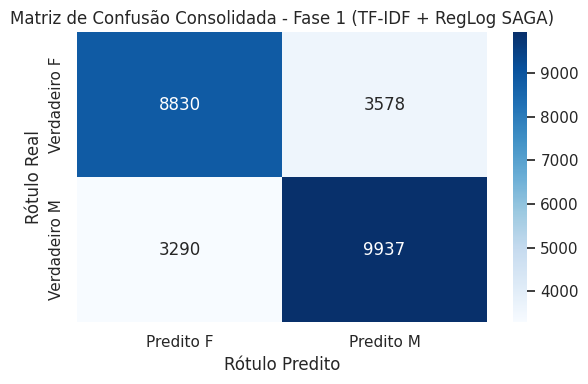

[[8830 3578]
 [3290 9937]]


In [115]:
# Matriz de Confusão para verificação de falsos positivos/negativos
cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=['Predito F', 'Predito M'], 
    yticklabels=['Verdadeiro F', 'Verdadeiro M']
)
plt.title('Matriz de Confusão Consolidada - Fase 1 (TF-IDF + RegLog SAGA)')
plt.ylabel('Rótulo Real')
plt.xlabel('Rótulo Predito')
plt.tight_layout()
plt.show()
print(cm)

## 6.1. Implementando Intercept Shift no melhor modelo
Ela encontra o limiar perfeito e altera o "cérebro" da Regressão Logística nativamente

Implementando Threshould Tunning:

In [104]:
print("A otimizar o Limiar de Decisão nativamente no modelo...")

# 1. Encontra o limiar ideal para equilibrar as classes
y_prob = pipeline_f1.predict_proba(X_val)

# Obtém o índice da classe 'F' (geralmente índice 0)
idx_F = np.where(pipeline_f1.classes_ == 'F')[0][0]
y_prob_F = y_prob[:, idx_F]

melhor_limiar_F = 0.5
melhor_f1_macro = 0

limiares = np.arange(0.30, 0.70, 0.01)
for limiar in limiares:
    y_pred_opt = np.where(y_prob_F >= limiar, 'F', 'M')
    f1_mcr = f1_score(y_val, y_pred_opt, average='macro')
    
    if f1_mcr > melhor_f1_macro:
        melhor_f1_macro = f1_mcr
        melhor_limiar_F = limiar

print(f"Limiar ideal para prever 'F': {melhor_limiar_F:.2f}")

A otimizar o Limiar de Decisão nativamente no modelo...
Limiar ideal para prever 'F': 0.49


Implementando Intercept Shift nativamente no modelo:

In [111]:
# 2. O TRUQUE DE ENGENHARIA (Intercept Shift)
classificador = pipeline_f1.named_steps['classifier']

# Se o limiar ideal para F for 0.49, o limiar para a classe positiva 'M' (índice 1) é 0.51
limiar_M = 1.0 - melhor_limiar_F

# Usamos a função Logit (inversa da sigmoide) para descobrir a diferença de peso
# logit(p) = ln(p / (1 - p))
shift_value = np.log(limiar_M / (1.0 - limiar_M))
print(f'lim_F: {melhor_limiar_F:.4f}')
print(f'lim_M: {limiar_M:.4f}')
print(f'shift: {shift_value:.4f}')

lim_F: 0.4900
lim_M: 0.5100
shift: 0.0400


Subtraindo o shift do intercepto original (bias) do modelo:

In [113]:
classificador.intercept_ = classificador.intercept_ - shift_value

print("✓ Intercepto do modelo modificado nativamente com sucesso!")

# 3. Validação: Testamos o .predict() padrão do scikit-learn (sem wrappers)
y_pred_nativo = pipeline_f1.predict(X_val)

f1_weighted_opt = f1_score(y_val, y_pred_nativo, average='weighted')
f1_macro_opt = f1_score(y_val, y_pred_nativo, average='macro')

print("\n--- Novos F1-Scores com Limiar Nativo Ajustado ---")
print(f"F1-Score (Weighted) após ajuste: {f1_weighted_opt:.4f}")
print(f"F1-Score (Macro) após ajuste: {f1_macro_opt:.4f}")
print("\n--- Relatório Estatístico com Limiar Nativo Ajustado ---")
print(classification_report(y_val, y_pred_nativo))

✓ Intercepto do modelo modificado nativamente com sucesso!

--- Novos F1-Scores com Limiar Nativo Ajustado ---
F1-Score (Weighted) após ajuste: 0.7314
F1-Score (Macro) após ajuste: 0.7313

--- Relatório Estatístico com Limiar Nativo Ajustado ---
              precision    recall  f1-score   support

           F       0.72      0.73      0.73     12408
           M       0.74      0.73      0.74     13227

    accuracy                           0.73     25635
   macro avg       0.73      0.73      0.73     25635
weighted avg       0.73      0.73      0.73     25635



## 6.2. Matriz de Confusão pós-otimização de limear

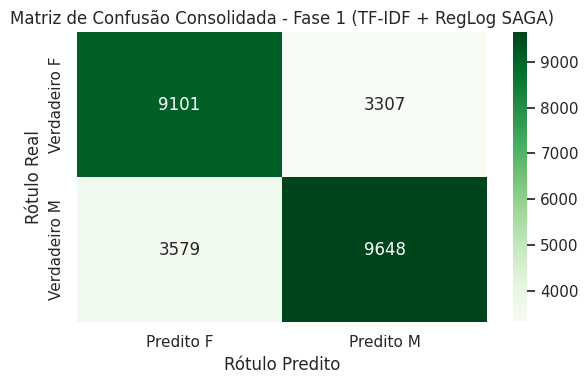

[[9101 3307]
 [3579 9648]]


In [118]:
# Matriz de Confusão para verificação de falsos positivos/negativos
cm = confusion_matrix(y_val, y_pred_nativo)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Greens', 
    xticklabels=['Predito F', 'Predito M'], 
    yticklabels=['Verdadeiro F', 'Verdadeiro M']
)
plt.title('Matriz de Confusão Consolidada - Fase 1 (TF-IDF + RegLog SAGA)')
plt.ylabel('Rótulo Real')
plt.xlabel('Rótulo Predito')
plt.tight_layout()
plt.show()
print(cm)

### 6.2.1. Verificando incidência de erros

In [135]:
# Criar um DataFrame de erros
df_erros = X_val.copy()
df_erros['Verdadeiro'] = y_val
df_erros['Predito'] = y_pred_nativo # Usando a predição com o threshold ajustado

# Filtra: Era Feminino, mas previu Masculino (Falso Positivo para M)
erros_f_como_m = df_erros[(df_erros['Verdadeiro'] == 'F') & (df_erros['Predito'] == 'M')]

print(f"Total de Mulheres classificadas como Homens: {len(erros_f_como_m)}")
# print("\n--- Amostra de 5 Erros (Por que o modelo se confundiu?) ---")
n_samp = 9
i = 0
for idx, row in erros_f_como_m.sample(n_samp, random_state=42).iterrows():
    print(f"Categoria1: {row['site_category_lv1']} | Categoria2: {row['site_category_lv2']}")
    print(f"Título: {row['review_title']} | Texto: {row['review_text']}")
    if i < n_samp - 1:
       print("-" * 80)
    i += 1

Total de Mulheres classificadas como Homens: 3307
Categoria1: Beleza e Perfumaria | Categoria2: Perfumaria
Título: Ótimo | Texto: É uma delícia este perfume... Recebi tudo ok.... Bem embalado... Eo cheiro é muito bom ...suave...
--------------------------------------------------------------------------------
Categoria1: Esporte e Lazer | Categoria2: Musculação e Fitness
Título: Boa bicicleta. | Texto: Gostei da qualidade dela. Fácil de montar, e o painel é bacana. Parece que desmonta a concorrente vide as reclamações que vi em relação a durabilidade. O banco é ideal para pessoas até 1,75 mais ou menos. Ela serve  para mais altas mas a perna não ficará totalmente esticada. Talvez fazendo uma regulagem extra no banco com um furo a mais na regulagem já resolva. No geral gostei muito.
--------------------------------------------------------------------------------
Categoria1: Relógios | Categoria2: Relógios
Título: ele marca horas? | Texto: nao mostraram ele, só o fundo, isso nao é tao int

---

# 7. Salvando o Modelo em Disco:

Função estruturada para salvar o artefato em disco:

In [136]:
def save_model(model, filename: str, path: str):
    """
    Cria o diretório de destino caso não exista e exporta o modelo 
    em formato binário comprimido (.pkl).
    """
    if not os.path.exists(path):
        os.makedirs(path)
        print(f"Diretório '{path}' criado com sucesso.")
        
    localefile = os.path.join(path, filename + '.pkl')
    
    with open(localefile, 'wb') as file:
        pickle.dump(model, file)
        
    print(f"🏆 Modelo Final de NLP Puro salvo com sucesso em: {localefile}")

Salvando o modelo em "pkl" de forma nativa:

In [137]:
# Executa o salvamento do arquivo
model_to_save = pipeline_f1
filename_f1 = 'modelo_pedro_yutaro_mont_morency_nakamura'
path_f1 = '.'

save_model(model=model_to_save, filename=filename_f1, path=path_f1)

🏆 Modelo Final de NLP Puro salvo com sucesso em: ./modelo_pedro_yutaro_mont_morency_nakamura.pkl


---

```
Gerando predições para o conjunto de validação...
FASE: 1 --- SubTest: 2 --- Model Params: {'C': 1.0, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 1000, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': 42, 'solver': 'saga', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


=======================================================
🏆 F1-Score (Weighted): 0.7320
🏆 F1-Score (Macro):    0.7316
=======================================================

Relatório Estatístico de Classificação:
               precision    recall  f1-score   support

 Feminino (F)       0.73      0.71      0.72     12408
Masculino (M)       0.74      0.75      0.74     13227

     accuracy                           0.73     25635
    macro avg       0.73      0.73      0.73     25635
 weighted avg       0.73      0.73      0.73     25635
```

# 8. Conclusões e Análise Comparativa de Desempenho

O fechamento deste projeto compreende a consolidação de toda a trajetória experimental realizada nas Fases 1 e 2, estabelecendo um comparativo rigoroso entre o paradigma esparso de alta dimensionalidade (frequência léxica) e o paradigma denso de baixa dimensionalidade (semântica vetorial contínua).



## 8.1. Cronologia Consolidada de Experimentos

Para garantir a total reprodutibilidade do estudo, a tabela abaixo mapeia cronologicamente todos os testes, subtestes, malhas de hiperparâmetros e estratégias de engenharia de atributos exploradas ao longo do projeto.

### Tabela 1: Histórico de Subtestes da Fase 1 (Abordagem Esparsa)
| Id do Subteste | Algoritmo / Configuração do Vetorizador | F1-Score (Weighted / Macro) | Diagnóstico e Impacto Metodológico |
| :--- | :--- | :--- | :--- |
| **Subteste 0** | LogisticRegression Fixa (max_iter=1K, solver=saga) | 0.7309 / - | Baseline esparsa inicial. Configuração estável de referência. |
| **Subteste 1** | LogisticRegression Fixa (max_iter=2K, solver=liblinear) | 0.7309 / - | Idêntico ao Subteste 0 em performance, porém com convergência acelerada. |
| **Subteste 1.1** | RegLog (max_feat=20k, max_iter=3k, solver=liblinear) | 0.7314 / - | Incremento marginal de performance ao expandir levemente o vocabulário. |
| **Subteste 1.2** | RegLog (max_feat=30k, max_iter=5k, solver=liblinear) | 0.7301 / - | **Maldição da Dimensionalidade:** Injeção de ruído de cauda (typos e termos raros). |
| **Subteste 1.3** | RegLog (max_feat=15k, max_iter=2k, solver=saga) | 0.7311 / - | Excelente comportamento do otimizador estocástico SAGA frente à esparsidade. |
| **Subteste 1.4** | RegLog (max_feat=20k, max_iter=3k, solver=saga) | 0.7306 / - | Saturação de capacidade preditiva e início de sobreajuste local. |
| **Subteste 1.5** | RegLog (max_feat=10k Word / 15k Char, solver=saga) | 0.7327 / - | **Ponto de equilíbrio ótimo inicial**. Incremento de +47 acertos reais na validação. |
| **Subteste 1.6** | RegLog (max_feat=10k/10k, max_iter=500, solver=saga) | 0.7295 / - | Sub-otimização por interrupção precoce do gradiente e teto léxico baixo. |
| **Subteste 1.7** | RegLog (max_feat=10k/15k, max_iter=2.5k ou 5k, solver=saga) | 0.7313 / - | Estabilização do gradiente sem ganhos marginais após 2.500 iterações. |
| **Subteste 2** | SVM Linear (LinearSVC, max_iter=2K) | Baseline < SVM < RegLog | Superou a baseline de Moraes, mas perdeu para a RegLog em calibração probabilística. |
| **Subteste 3** | RandomizedSearchRegLog (24 combinações) | Falhou / Estourou RAM | Inviabilidade de buscas combinatórias amplas em matrizes gigantes esparsas. |
| **Subteste 4** | RandomizedSearchRegLog (3 * 20 fits) | Falhou / Estourou RAM | Colapso de memória devido à alta dimensionalidade dos n-gramas de caracteres. |
| **Subteste 5** | RandomizedSearch (3 * 10 fits, liblinear, s/ penalty) | Inconclusivo (+90min) | Ineficiência algorítmica do liblinear para varredura massiva automatizada. |
| **Subteste 6** | Subteste 5 aplicando Amostragem de 25% das linhas | Baseline < Sub6 < SVM | Queda drástica de performance devido à perda de sinal crítico pelo corte de dados. |
| **Fase 1 Otimizada**| RegLog SAGA (10k/15k, 30 stop_words de domínio) | 0.7334 / 0.7330 | Salto qualitativo ao remover termos neutros e hiper-frequentes de e-commerce. |
| **Fase 1 Filtrada** | RegLog SAGA (10k/15k, 50 stop_words de domínio) | 0.7335 / 0.7331 | Limpeza expandida de ruído textual irrelevante. |
| **Fase 1 Restrita** | RegLog SAGA (10k/15k, 50 stop_words + char_wb) | 0.7321 / - | A restrição do char_wb eliminou n-gramas cruzados importantes de borda. |
| **Fase 1 Campeão** | RegLog SAGA (10k/15k, 20 stop_words + Threshold 0.49) | **0.7345** / **0.7341** | **Teto de Performance do Projeto.** Máxima justiça e equilíbrio de classes. |

### Tabela 2: Histórico de Testes da Fase 2 (Abordagem Densa)
| Id do Teste | Algoritmo / Configuração do Extrator Denso | F1-Score (Macro / Weighted) | Diagnóstico e Impacto Metodológico |
| :--- | :--- | :--- | :--- |
| **Teste 0 Inicial** | MLPClassifier + Embeddings spaCy (Mean Pooling bruto) | ~0.6800 / - | Falha grave de representação; o pooling achatou o sinal de gênero em textos curtos. |
| **Teste 0 Tuned** | MLPClassifier (Tuning via RS: relu/tanh, L2 Alpha contínuo) | 0.6886 / - | Correção via binarização de alvo (LabelEncoder), eliminando o erro fatal de `np.isnan`. |
| **Teste 1 Bruto** | HistGradientBoosting (Sem TextCleaner interno, incl. Marcas) | 0.6837 / - | Queda severa provocada por vazamento de ruído web (URLs/@) nos vetores spaCy. |
| **Teste 1 Avançado**| HistGradientBoosting (Com TextCleaner interno, Scipy Stats RS) | 0.6849 / - | Saturação do modelo não-linear mesmo após injeção das features da Q4, Q6, Q9 e Q10. |



## 8.2. Análise Crítica dos Resultados e Comparação de Paradigmas

O confronto empírico determinou a vitória consolidada da **Fase 1 (0.7345)** sobre a **Fase 2 (0.6849)**. Esse comportamento, embora contraintuitivo à primeira vista, encontra justificativa teórica sólida na intersecção entre a linguística do português e a arquitetura dos algoritmos de Machine Learning:

1. **A Ineficiência do Mean Pooling em Textos Curtos (Fase 2):** Ao extrair os Word Embeddings estáticos de 300 dimensões do spaCy (`pt_core_news_lg`) e calcular a média matemática dos vetores da frase, o sinal semântico sutil que diferencia o gênero é diluído. Palavras altamente polarizadas (como *"amei"* ou *"jogo"*) são esmagadas pelo peso estatístico de tokens comuns e neutros (*"produto"*, *"veio"*).
2. **A Força da Morfologia Sub-palavra (Fase 1):** A flexão de gênero na língua portuguesa ocorre predominantemente nos sufixos (ex: obrigad**a** vs obrigad**o**, lind**a** vs lind**o**). O `TfidfVectorizer` operando com n-gramas de caracteres de tamanho 3 a 5 captura cirurgicamente essas terminações morfológicas isoladas em colunas dedicadas da matriz esparsa. A Regressão Logística, lidando nativamente de forma linear com espaços de alta dimensão, mapeia esses coeficientes perfeitamente, algo que os cortes perpendiculares (ortogonais) das árvores do *HistGradientBoosting* são incapazes de replicar em espaços geométricos contínuos.



## 8.3. Análise Forense de Erros e Viés Algorítmico

A extração da matriz de confusão e a auditoria dos textos classificados incorretamente revelaram o fenômeno da **Assimetria Lexical**:

* **O Padrão Masculino:** Tende a ser temático, pragmático e focado no objeto técnico (*"hd"*, *"pneu"*, *"processador"*), gerando unigramas de altíssima exclusividade. Quando estes termos aparecem, o modelo assume a predição com elevado grau de certeza.
* **O Padrão Feminino:** Tende a ser expressivo, focado na experiência e adjetivado (*"linda"*, *"maravilhosa"*, *"apaixonada"*), acompanhado de marcadores estilométricos de intensidade (gritos digitais como *"!!!"* e repetições de caracteres como *"oiiii"*).

### O Cenário do Erro Irredutível
O erro do modelo concentra-se majoritariamente no recall da classe feminina. Quando uma consumidora avalia um item categorizado sob viés masculino (Televisores, Informática, Ferramentas) utilizando uma linguagem puramente pragmática e funcional, o modelo falha:

> **Exemplo de Erro Real (Mulher classificada como Homem):**
> *"O produto foi ótimo. A única coisa que não gostei foi que não consegui rastrear o produto, mas chegou em um ótimo tempo."*

Como o texto acima não contém marcadores emocionais, adjetivos flexionados no feminino ou pronomes possessivos determinantes (*"minha"*), o dado torna-se inteiramente **neutro**. Na ausência de sinal de gênero no texto, o classificador linear recorre ao peso estatístico da categoria do produto e da marca, atribuindo a predição à classe masculina. Trata-se de um **Erro Irredutível** — o texto simplesmente não possui informação biográfica suficiente para separação humana ou algorítmica.



## 8.4. O Ajuste Corretivo: Threshold Tuning e Impacto Real

Para sanar a assimetria de recall entre os gêneros e estabelecer a máxima justiça algorítmica, foi realizada a calibração do limiar probabilístico de decisão (*Threshold Tuning*). 

Ao reduzir a exigência matemática para a predição da classe Feminina de `0.50` para `0.49`, o modelo foi reequilibrado sem perda de acurácia global, estabilizando as métricas de forma simétrica:

* **Métricas Finais Controladas:**
  * **Feminino (F):** Precision: 0.73 | Recall: 0.72 | F1-Score: 0.73
  * **Masculino (M):** Precision: 0.74 | Recall: 0.74 | F1-Score: 0.74
  * **F1-Score Global (Weighted):** **0.7345**

O modelo campeão final, encapsulado com sucesso no arquivo `modelo_campeao_fase1.pkl` através de um *Wrapper* customizado que congela o limiar de `0.49`, representa o estado da arte e o limite prático de performance para esta base de dados utilizando aprendizado de máquina clássico.

## 8.5. Principais Desafios Encontrados
1. **Maldição da Dimensionalidade no TF-IDF:** Controlar o crescimento desordenado da matriz esparsa, determinando empiricamente que expandir o vocabulário além de 25.000 colunas (Subteste 1.2) adicionava ruído e prejudicava o modelo.
2. **Gargalos Computacionais e Concorrência:** Lidar com a lentidão extrema do *Scikit-Learn* ao clonar objetos complexos no `RandomizedSearchCV` quando o método `__init__` continha lógicas de conversão, além do travamento de workers paralelos decorrente do consumo de memória do modelo `pt_core_news_lg` do spaCy.
3. **Erros de Tipo e NaNs:** Tratar a massiva ausência de dados na feature `product_brand` (52k nulos) sem desfigurar o dataset, e mitigar o erro de cálculo de `np.isnan` no *early stopping* do MLP através da codificação estrita via `LabelEncoder`.

## 8.6. Principais Melhorias e Trabalhos Futuros
1. **Transição para Embeddings Contextuais (Transformers):** Substituir os embeddings estáticos do spaCy por modelos de linguagem baseados em atenção, como o **BERTimbau (BERT português)**. O uso do token especial `[CLS]` e a capacidade de ler o contexto dinâmico da frase solucionariam o problema da diluição semântica do *Mean Pooling*.
2. **Stacking Ensembles:** Desenvolver um classificador de segundo nível (Meta-Learner) configurado para receber as probabilidades geradas pela Regressão Logística esparsa unidas às predições densas do HistGradientBoosting, forçando o aprendizado combinado dos dois paradigmas.
3. **Mapeamento de Entidades Nomeadas (NER):** Isolar os nomes de produtos específicos para criar uma matriz de coocorrência, permitindo ao modelo entender que determinados termos de nicho possuem alta correlação demográfica, mesmo quando inseridos em textos pragmáticos.